# Swin-Tiny two-stage training for plant disease classification
This notebook builds a **disease-only pipeline** from  original `train/` and `val/` folders, then trains **Swin-Tiny** in two stages:
1. **Head-only** training
2. **Last Swin stage + head** fine-tuning

It keeps `official val` untouched as test, uses strict folder parsing, and saves analysis artifacts.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

!pip -q install timm pandas scikit-learn seaborn pillow


In [ ]:

import os, re, json, math, shutil, random, hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

CFG = {
    "data_root": "/content/drive/MyDrive/Metric_Dataset",
    "work_root": "/content/drive/MyDrive/swin_tiny_runs",
    "run_name": "swin_tiny_two_stage",

    "target_label_mode": "disease",
    "dev_ratio": 0.15,
    "seed": 42,
    "remove_exact_duplicates_by_sha1": False,

    "model_name": "swin_tiny_patch4_window7_224",
    "imgsz": 384,
    "batch_size": 16,
    "num_workers": 2,

    "flip_horizontal": True,
    "rotation_deg": round(0.08 * 360),
    "translate": 0.08,
    "scale_low": 0.90,
    "scale_high": 1.10,
    "brightness": 0.10,
    "contrast": 0.10,

    "epochs_stage1": 10,
    "lr_stage1": 1e-3,
    "epochs_stage2": 15,
    "lr_stage2": 2e-5,

    "weight_decay": 1e-4,
    "dropout": 0.30,
    "patience": 5,
    "use_class_weights": True,
    "use_weighted_sampler": False,

    "save_train_predictions": True,
}

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
KNOWN_PLANTS = sorted(
    {
        "apple", "banana", "basil", "bean", "bell pepper", "blueberry",
        "broccoli", "cabbage", "cauliflower", "celery", "cherry", "citrus",
        "coffee", "corn", "maize", "cucumber", "garlic", "ginger", "grape",
        "lettuce", "maple", "orange", "peach", "pepper", "plum", "potato",
        "raspberry", "rice", "soybean", "squash", "strawberry", "tomato",
        "tobacco", "wheat", "zucchini",
    },
    key=lambda x: len(x.split()),
    reverse=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG["seed"])


device: cuda
gpu: Tesla T4


In [ ]:

def normalize_text(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"[_-]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s

def safe_class_dir_name(label: str) -> str:
    label = normalize_text(label)
    label = re.sub(r"[^\w\s()]", "", label)
    label = re.sub(r"\s+", "_", label)
    return label

def sha1_file(path: str, chunk_size: int = 1 << 20) -> str:
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def parse_folder_label_strict(folder_name: str, known_plants):
    folder_norm = normalize_text(folder_name)
    if folder_norm in MANUAL_FOLDER_TO_LABEL:
        item = MANUAL_FOLDER_TO_LABEL[folder_norm]
        return normalize_text(item["plant"]), normalize_text(item["disease"])

    tokens = folder_norm.split()
    for plant in known_plants:
        pt = plant.split()
        if tokens[:len(pt)] == pt:
            disease = " ".join(tokens[len(pt):]).strip()
            if not disease:
                raise ValueError(f"Folder '{folder_name}' matched plant '{plant}' but disease is empty.")
            return plant, disease
    raise ValueError(
        f"Could not strictly parse folder '{folder_name}'. "
        f"It does not start with a known plant name. Add it to MANUAL_FOLDER_TO_LABEL if needed."
    )

def collect_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    if not split_dir.exists():
        raise FileNotFoundError(f"{split_dir} does not exist")

    rows = []
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        plant, disease = parse_folder_label_strict(class_dir.name, KNOWN_PLANTS)
        folder_name = normalize_text(class_dir.name)
        for root, _, files in os.walk(class_dir):
            for fname in files:
                ext = Path(fname).suffix.lower()
                if ext in IMG_EXTENSIONS:
                    rows.append({
                        "official_split": split_name,
                        "file_path": str(Path(root) / fname),
                        "folder_name": folder_name,
                        "plant": plant,
                        "disease": disease,
                        "full_label": folder_name,
                    })
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No images found in {split_dir}")
    return df

def print_and_save_dataset_stats(df_all: pd.DataFrame, train_df: pd.DataFrame, out_dir: Path):
    plants = sorted(df_all["plant"].unique().tolist())
    classes = sorted(df_all["target_label"].unique().tolist())

    plant_counts = df_all.groupby("plant").size().reset_index(name="count").sort_values("count", ascending=False)
    class_counts = df_all.groupby("target_label").size().reset_index(name="count").sort_values("count", ascending=False)
    train_class_counts = train_df.groupby("target_label").size().reset_index(name="train_count").sort_values("train_count", ascending=False)

    with open(out_dir / "dataset_summary.txt", "w", encoding="utf-8") as f:
        f.write(f"Number of plants: {len(plants)}\n")
        f.write("Plant names:\n")
        for p in plants:
            f.write(f"- {p}\n")
        f.write(f"\nNumber of classes: {len(classes)}\n")
        f.write("Class names:\n")
        for c in classes:
            f.write(f"- {c}\n")
        f.write(f"\nNumber of images in train dataset: {len(train_df)}\n")

    plant_counts.to_csv(out_dir / "number_per_plant.csv", index=False)
    class_counts.to_csv(out_dir / "number_per_class_all_splits.csv", index=False)
    train_class_counts.to_csv(out_dir / "number_per_class_train_only.csv", index=False)

    print("=" * 90)
    print(f"Number of plants: {len(plants)}")
    print(plants)
    print(f"Number of classes: {len(classes)}")
    print(classes)
    print(f"Number of images in train dataset: {len(train_df)}")
    print("Top class counts (all splits):")
    print(class_counts.head(20).to_string(index=False))
    print("Top plant counts:")
    print(plant_counts.head(20).to_string(index=False))
    print("=" * 90)


In [ ]:

data_root = Path(CFG["data_root"])
run_root = Path(CFG["work_root"]) / CFG["run_name"]
if run_root.exists():
    shutil.rmtree(run_root)
run_root.mkdir(parents=True, exist_ok=True)

official_train_df = collect_split(data_root / "train", "train")
official_val_df = collect_split(data_root / "val", "official_val")

label_col = "disease" if CFG["target_label_mode"] == "disease" else "full_label"
official_train_df["target_label"] = official_train_df[label_col]
official_val_df["target_label"] = official_val_df[label_col]

if CFG["remove_exact_duplicates_by_sha1"]:
    print("Computing SHA1 hashes...")
    official_train_df["sha1"] = official_train_df["file_path"].map(sha1_file)
    official_val_df["sha1"] = official_val_df["file_path"].map(sha1_file)
    val_hashes = set(official_val_df["sha1"].tolist())
    before = len(official_train_df)
    official_train_df = official_train_df.loc[~official_train_df["sha1"].isin(val_hashes)].reset_index(drop=True)
    print(f"Removed {before - len(official_train_df)} train rows duplicated in official val.")
else:
    official_train_df["sha1"] = ""
    official_val_df["sha1"] = ""

train_sub_df, dev_sub_df = train_test_split(
    official_train_df,
    test_size=CFG["dev_ratio"],
    random_state=CFG["seed"],
    shuffle=True,
    stratify=official_train_df["target_label"],
)
train_sub_df = train_sub_df.reset_index(drop=True)
dev_sub_df = dev_sub_df.reset_index(drop=True)
official_val_df = official_val_df.reset_index(drop=True)

manifest = pd.concat(
    [train_sub_df.assign(split="train"), dev_sub_df.assign(split="val"), official_val_df.assign(split="test")],
    ignore_index=True,
)
classes = sorted(manifest["target_label"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
manifest["label_idx"] = manifest["target_label"].map(class_to_idx)

manifest.to_csv(run_root / "manifest_all_splits.csv", index=False)
with open(run_root / "label_map.json", "w", encoding="utf-8") as f:
    json.dump(
        {"classes": classes, "class_to_idx": class_to_idx, "idx_to_class": idx_to_class, "target_label_mode": CFG["target_label_mode"]},
        f, ensure_ascii=False, indent=2
    )

print_and_save_dataset_stats(manifest, train_sub_df, run_root)

path_intersections = {
    "train_val": len(set(train_sub_df["file_path"]) & set(dev_sub_df["file_path"])),
    "train_test": len(set(train_sub_df["file_path"]) & set(official_val_df["file_path"])),
    "val_test": len(set(dev_sub_df["file_path"]) & set(official_val_df["file_path"])),
}
print("Path intersections:", path_intersections)
assert all(v == 0 for v in path_intersections.values())


Number of plants: 32
['apple', 'banana', 'basil', 'bean', 'bell pepper', 'blueberry', 'broccoli', 'cabbage', 'cauliflower', 'celery', 'cherry', 'citrus', 'coffee', 'corn', 'cucumber', 'garlic', 'ginger', 'grape', 'lettuce', 'maple', 'peach', 'plum', 'potato', 'raspberry', 'rice', 'soybean', 'squash', 'strawberry', 'tobacco', 'tomato', 'wheat', 'zucchini']
Number of classes: 39
['alternaria leaf spot', 'angular leaf spot', 'anthracnose', 'bacterial leaf spot', 'bacterial leaf streak (black chaff)', 'bacterial wilt', 'berry blotch', 'black leaf streak', 'black rot', 'blossom end rot', 'brown rot', 'brown spot', 'bunchy top', 'canker', 'downy mildew', 'early blight', 'frog eye leaf spot', 'gray leaf spot', 'greening disease', 'head scab', 'late blight', 'leaf curl', 'leaf mold', 'leaf rust', 'leaf spot', 'loose smut', 'mosaic', 'mosaic virus', 'northern leaf blight', 'powdery mildew', 'rust', 'scab', 'septoria blotch', 'septoria leaf spot', 'sheath blight', 'smut', 'stem rust', 'stripe ru

In [ ]:
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import numpy as np
import torch


classes = sorted(manifest["target_label"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

manifest["label_idx"] = manifest["target_label"].map(class_to_idx)
train_sub_df["label_idx"] = train_sub_df["target_label"].map(class_to_idx)
dev_sub_df["label_idx"] = dev_sub_df["target_label"].map(class_to_idx)
official_val_df["label_idx"] = official_val_df["target_label"].map(class_to_idx)

# Optional safety check
assert train_sub_df["label_idx"].notna().all(), "Missing label_idx in train_sub_df"
assert dev_sub_df["label_idx"].notna().all(), "Missing label_idx in dev_sub_df"
assert official_val_df["label_idx"].notna().all(), "Missing label_idx in official_val_df"

train_sub_df["label_idx"] = train_sub_df["label_idx"].astype(int)
dev_sub_df["label_idx"] = dev_sub_df["label_idx"].astype(int)
official_val_df["label_idx"] = official_val_df["label_idx"].astype(int)

# --------------------------------------------------
# Transforms
# --------------------------------------------------
class PadToSquareResize:
    def __init__(self, size, fill=(114, 114, 114)):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        return ImageOps.pad(
            img,
            (self.size, self.size),
            color=self.fill,
            method=Image.BILINEAR
        )

train_tf = transforms.Compose([
    PadToSquareResize(CFG["imgsz"]),
    transforms.RandomHorizontalFlip(p=0.5 if CFG["flip_horizontal"] else 0.0),
    transforms.RandomAffine(
        degrees=CFG["rotation_deg"],
        translate=(CFG["translate"], CFG["translate"]),
        scale=(CFG["scale_low"], CFG["scale_high"]),
        fill=114,
    ),
    transforms.ColorJitter(
        brightness=CFG["brightness"],
        contrast=CFG["contrast"]
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

eval_tf = transforms.Compose([
    PadToSquareResize(CFG["imgsz"]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

# --------------------------------------------------
# Dataset
# --------------------------------------------------
class DiseaseDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["file_path"]).convert("RGB")
        img = self.transform(img)
        y = int(row["label_idx"])
        return img, y

train_ds = DiseaseDataset(train_sub_df, train_tf)
val_ds = DiseaseDataset(dev_sub_df, eval_tf)
test_ds = DiseaseDataset(official_val_df, eval_tf)

# --------------------------------------------------
# Optional weighted sampler
# --------------------------------------------------
train_labels = train_sub_df["label_idx"].to_numpy()
sampler = None

if CFG["use_weighted_sampler"]:
    cls_counts = np.bincount(train_labels, minlength=len(classes))
    sample_w = 1.0 / np.maximum(cls_counts[train_labels], 1)
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_w, dtype=torch.double),
        num_samples=len(sample_w),
        replacement=True,
    )

# pin_memory is useful only if CUDA is available
use_pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=CFG["num_workers"],
    pin_memory=use_pin_memory,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=use_pin_memory,
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=use_pin_memory,
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))
print("n_classes:", len(classes))
print("sample train labels:", train_sub_df["label_idx"].head().tolist())

train batches: 414
val batches: 73
test batches: 25
n_classes: 39
sample train labels: [1, 37, 33, 10, 14]


In [ ]:

model = timm.create_model(
    CFG["model_name"],
    pretrained=True,
    num_classes=len(classes),
    drop_rate=CFG["dropout"],
    img_size=CFG["imgsz"],
    dynamic_img_size=True,


)
model = model.to(device)
print(model)


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [ ]:

def set_trainable_stage1(model):
    for p in model.parameters():
        p.requires_grad = False
    if hasattr(model, "head"):
        for p in model.head.parameters():
            p.requires_grad = True
    else:
        raise RuntimeError("Expected timm Swin model to have .head")

def set_trainable_stage2(model):
    for p in model.parameters():
        p.requires_grad = False
    if hasattr(model, "layers"):
        for p in model.layers[-1].parameters():
            p.requires_grad = True
    if hasattr(model, "norm"):
        for p in model.norm.parameters():
            p.requires_grad = True
    if hasattr(model, "head"):
        for p in model.head.parameters():
            p.requires_grad = True

def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

if CFG["use_class_weights"]:
    cls_weights = compute_class_weight(class_weight="balanced", classes=np.arange(len(classes)), y=train_labels)
    class_weights = torch.tensor(cls_weights, dtype=torch.float32, device=device)
else:
    class_weights = None

def make_loss():
    return nn.CrossEntropyLoss(weight=class_weights)

def topk_hits(logits, y, k):
    topk = torch.topk(logits, k=min(k, logits.size(1)), dim=1).indices
    return (topk == y.unsqueeze(1)).any(dim=1).float().sum().item()

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total = 0
    correct1 = 0.0
    correct3 = 0.0
    correct5 = 0.0
    all_probs, all_true, all_pred = [], [], []

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)

        bs = y.size(0)
        total += bs
        total_loss += loss.item() * bs
        correct1 += (pred == y).float().sum().item()
        correct3 += topk_hits(logits, y, 3)
        correct5 += topk_hits(logits, y, 5)

        all_probs.append(probs.cpu().numpy())
        all_true.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

    return {
        "loss": total_loss / max(total, 1),
        "acc": correct1 / max(total, 1),
        "top3": correct3 / max(total, 1),
        "top5": correct5 / max(total, 1),
        "probs": np.concatenate(all_probs, axis=0),
        "y_true": np.concatenate(all_true, axis=0),
        "y_pred": np.concatenate(all_pred, axis=0),
    }

def train_stage(model, train_loader, val_loader, epochs, lr, stage_name):
    loss_fn = make_loss()
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_metric = -1.0
    best_state = None
    patience_ctr = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total = 0
        correct1 = 0.0
        correct3 = 0.0
        correct5 = 0.0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            total += bs
            total_loss += loss.item() * bs
            correct1 += (logits.argmax(dim=1) == y).float().sum().item()
            correct3 += topk_hits(logits, y, 3)
            correct5 += topk_hits(logits, y, 5)

        train_loss = total_loss / max(total, 1)
        train_acc = correct1 / max(total, 1)
        train_top3 = correct3 / max(total, 1)
        train_top5 = correct5 / max(total, 1)

        val_out = evaluate(model, val_loader, loss_fn)
        scheduler.step(val_out["loss"])

        row = {
            "stage": stage_name,
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_top3": train_top3,
            "train_top5": train_top5,
            "val_loss": val_out["loss"],
            "val_acc": val_out["acc"],
            "val_top3": val_out["top3"],
            "val_top5": val_out["top5"],
        }
        history.append(row)
        print(row)

        if val_out["acc"] > best_metric:
            best_metric = val_out["acc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= CFG["patience"]:
                print(f"Early stopping in {stage_name} at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return pd.DataFrame(history)


In [ ]:

set_trainable_stage1(model)
total, trainable = count_trainable_params(model)
print(f"Stage 1 trainable params: {trainable:,} / {total:,}")
for n, p in model.named_parameters():
    if p.requires_grad:
        print("trainable:", n)

hist1 = train_stage(model, train_loader, val_loader, CFG["epochs_stage1"], CFG["lr_stage1"], "stage1_head_only")
hist1.to_csv(run_root / "history_stage1.csv", index=False)
torch.save(model.state_dict(), run_root / "best_stage1_head_only.pth")


Stage 1 trainable params: 29,991 / 27,549,345
trainable: head.fc.weight
trainable: head.fc.bias
{'stage': 'stage1_head_only', 'epoch': 1, 'lr': 0.001, 'train_loss': 2.402476356359296, 'train_acc': 0.38306878306878306, 'train_top3': 0.6016628873771731, 'train_top5': 0.7076341647770219, 'val_loss': 1.6820743034963739, 'val_acc': 0.4965753424657534, 'val_top3': 0.7303082191780822, 'val_top5': 0.8296232876712328}
{'stage': 'stage1_head_only', 'epoch': 2, 'lr': 0.001, 'train_loss': 1.580607795102616, 'train_acc': 0.5295540438397581, 'train_top3': 0.7560090702947846, 'train_top5': 0.8486772486772487, 'val_loss': 1.3967540117159283, 'val_acc': 0.5488013698630136, 'val_top3': 0.7876712328767124, 'val_top5': 0.8698630136986302}
{'stage': 'stage1_head_only', 'epoch': 3, 'lr': 0.001, 'train_loss': 1.3355589828433543, 'train_acc': 0.5619047619047619, 'train_top3': 0.7945578231292517, 'train_top5': 0.8796674225245654, 'val_loss': 1.240060809540422, 'val_acc': 0.5625, 'val_top3': 0.800513698630137, 

In [ ]:

set_trainable_stage2(model)
total, trainable = count_trainable_params(model)
print(f"Stage 2 trainable params: {trainable:,} / {total:,}")
for n, p in model.named_parameters():
    if p.requires_grad:
        print("trainable:", n)

hist2 = train_stage(model, train_loader, val_loader, CFG["epochs_stage2"], CFG["lr_stage2"], "stage2_last_stage_plus_head")
hist2.to_csv(run_root / "history_stage2.csv", index=False)
torch.save(model.state_dict(), run_root / "best_stage2_last_stage_plus_head.pth")


Stage 2 trainable params: 15,398,103 / 27,549,345
trainable: layers.3.downsample.norm.weight
trainable: layers.3.downsample.norm.bias
trainable: layers.3.downsample.reduction.weight
trainable: layers.3.blocks.0.norm1.weight
trainable: layers.3.blocks.0.norm1.bias
trainable: layers.3.blocks.0.attn.relative_position_bias_table
trainable: layers.3.blocks.0.attn.qkv.weight
trainable: layers.3.blocks.0.attn.qkv.bias
trainable: layers.3.blocks.0.attn.proj.weight
trainable: layers.3.blocks.0.attn.proj.bias
trainable: layers.3.blocks.0.norm2.weight
trainable: layers.3.blocks.0.norm2.bias
trainable: layers.3.blocks.0.mlp.fc1.weight
trainable: layers.3.blocks.0.mlp.fc1.bias
trainable: layers.3.blocks.0.mlp.fc2.weight
trainable: layers.3.blocks.0.mlp.fc2.bias
trainable: layers.3.blocks.1.norm1.weight
trainable: layers.3.blocks.1.norm1.bias
trainable: layers.3.blocks.1.attn.relative_position_bias_table
trainable: layers.3.blocks.1.attn.qkv.weight
trainable: layers.3.blocks.1.attn.qkv.bias
trainabl

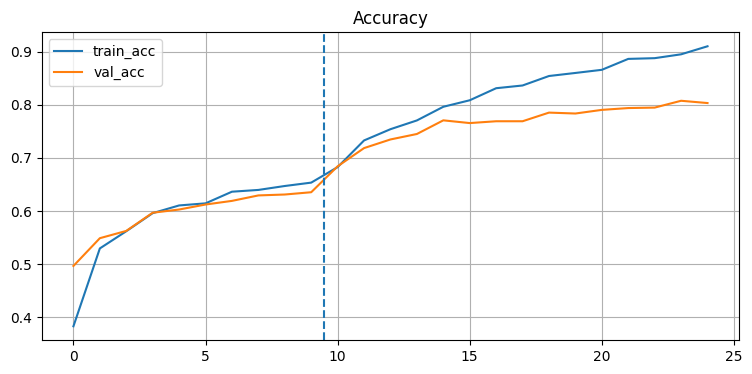

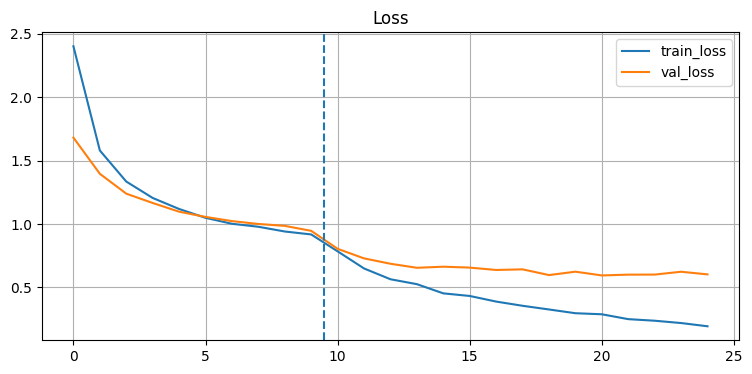

In [ ]:

hist = pd.concat([hist1, hist2], ignore_index=True)
hist.to_csv(run_root / "history_all.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(hist["train_acc"], label="train_acc")
plt.plot(hist["val_acc"], label="val_acc")
plt.axvline(len(hist1)-0.5, linestyle="--")
plt.grid(True); plt.legend(); plt.title("Accuracy")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(hist["train_loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.axvline(len(hist1)-0.5, linestyle="--")
plt.grid(True); plt.legend(); plt.title("Loss")
plt.show()


In [ ]:

@torch.no_grad()
def predict_df(model, df, loader, split_name):
    loss_fn = make_loss()
    out = evaluate(model, loader, loss_fn)

    probs = out["probs"]
    y_true = out["y_true"]
    y_pred = out["y_pred"]
    top1_conf = probs.max(axis=1)
    order = np.argsort(-probs, axis=1)

    pred_df = df.copy().reset_index(drop=True)
    pred_df["true_idx"] = y_true
    pred_df["pred_idx"] = y_pred
    pred_df["true_label"] = [idx_to_class[i] for i in y_true]
    pred_df["pred_label"] = [idx_to_class[i] for i in y_pred]
    pred_df["top1_conf"] = top1_conf
    pred_df["is_correct"] = (y_true == y_pred).astype(int)
    pred_df["top3_hit"] = [int(y in row[:3]) for y, row in zip(y_true, order)]
    pred_df["top5_hit"] = [int(y in row[:5]) for y, row in zip(y_true, order)]

    pred_df.to_csv(run_root / f"{split_name}_all_predictions_with_metadata.csv", index=False)
    pred_df[pred_df["is_correct"].eq(0)].to_csv(run_root / f"{split_name}_all_misclassifications.csv", index=False)
    return pred_df, out

def analyze_split(pred_df, split_name):
    y_true = pred_df["true_idx"].to_numpy()
    y_pred = pred_df["pred_idx"].to_numpy()

    metrics = {
        "split": split_name,
        "n_samples": int(len(pred_df)),
        "top1_acc": float(accuracy_score(y_true, y_pred)),
        "top3_acc": float(pred_df["top3_hit"].mean()),
        "top5_acc": float(pred_df["top5_hit"].mean()),
        "misclassified_count": int((pred_df["is_correct"] == 0).sum()),
    }
    with open(run_root / f"{split_name}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    report_df = pd.DataFrame(
        classification_report(y_true, y_pred, target_names=classes, digits=4, output_dict=True)
    ).T
    report_df.to_csv(run_root / f"{split_name}_classification_report.csv")

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
    pd.DataFrame(cm, index=classes, columns=classes).to_csv(run_root / f"{split_name}_confusion_matrix.csv")

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.title(f"Confusion Matrix - {split_name}")
    plt.tight_layout()
    plt.savefig(run_root / f"{split_name}_confusion_matrix.png", dpi=200)
    plt.show()

    mis = pred_df[pred_df["is_correct"].eq(0)].copy()
    mis.groupby("true_label").size().reset_index(name="misclassified_count").sort_values(
        "misclassified_count", ascending=False
    ).to_csv(run_root / f"{split_name}_most_misclassified_labels.csv", index=False)
    mis.groupby("plant").size().reset_index(name="misclassified_count").sort_values(
        "misclassified_count", ascending=False
    ).to_csv(run_root / f"{split_name}_most_misclassified_plants.csv", index=False)
    confusions = mis.groupby(["true_label", "pred_label"]).size().reset_index(name="count").sort_values(
        "count", ascending=False
    )
    confusions.to_csv(run_root / f"{split_name}_most_confusions_between_labels.csv", index=False)

    pair_counter = Counter()
    for _, r in confusions.iterrows():
        pair_counter[tuple(sorted((r["true_label"], r["pred_label"])))] += int(r["count"])
    pd.DataFrame(
        [{"class_a": a, "class_b": b, "symmetric_confusion": c} for (a, b), c in pair_counter.items()]
    ).sort_values("symmetric_confusion", ascending=False).to_csv(
        run_root / f"{split_name}_most_similar_classes_by_confusion.csv", index=False
    )

    pd.DataFrame(
        {
            "group": ["correct", "wrong"],
            "count": [int(pred_df["is_correct"].eq(1).sum()), int(pred_df["is_correct"].eq(0).sum())],
            "mean_conf": [
                float(pred_df.loc[pred_df["is_correct"].eq(1), "top1_conf"].mean()),
                float(pred_df.loc[pred_df["is_correct"].eq(0), "top1_conf"].mean()),
            ],
            "median_conf": [
                float(pred_df.loc[pred_df["is_correct"].eq(1), "top1_conf"].median()),
                float(pred_df.loc[pred_df["is_correct"].eq(0), "top1_conf"].median()),
            ],
        }
    ).to_csv(run_root / f"{split_name}_confidence_summary_correct_vs_wrong.csv", index=False)

    print(metrics)
    display(report_df.head(15))
    return metrics


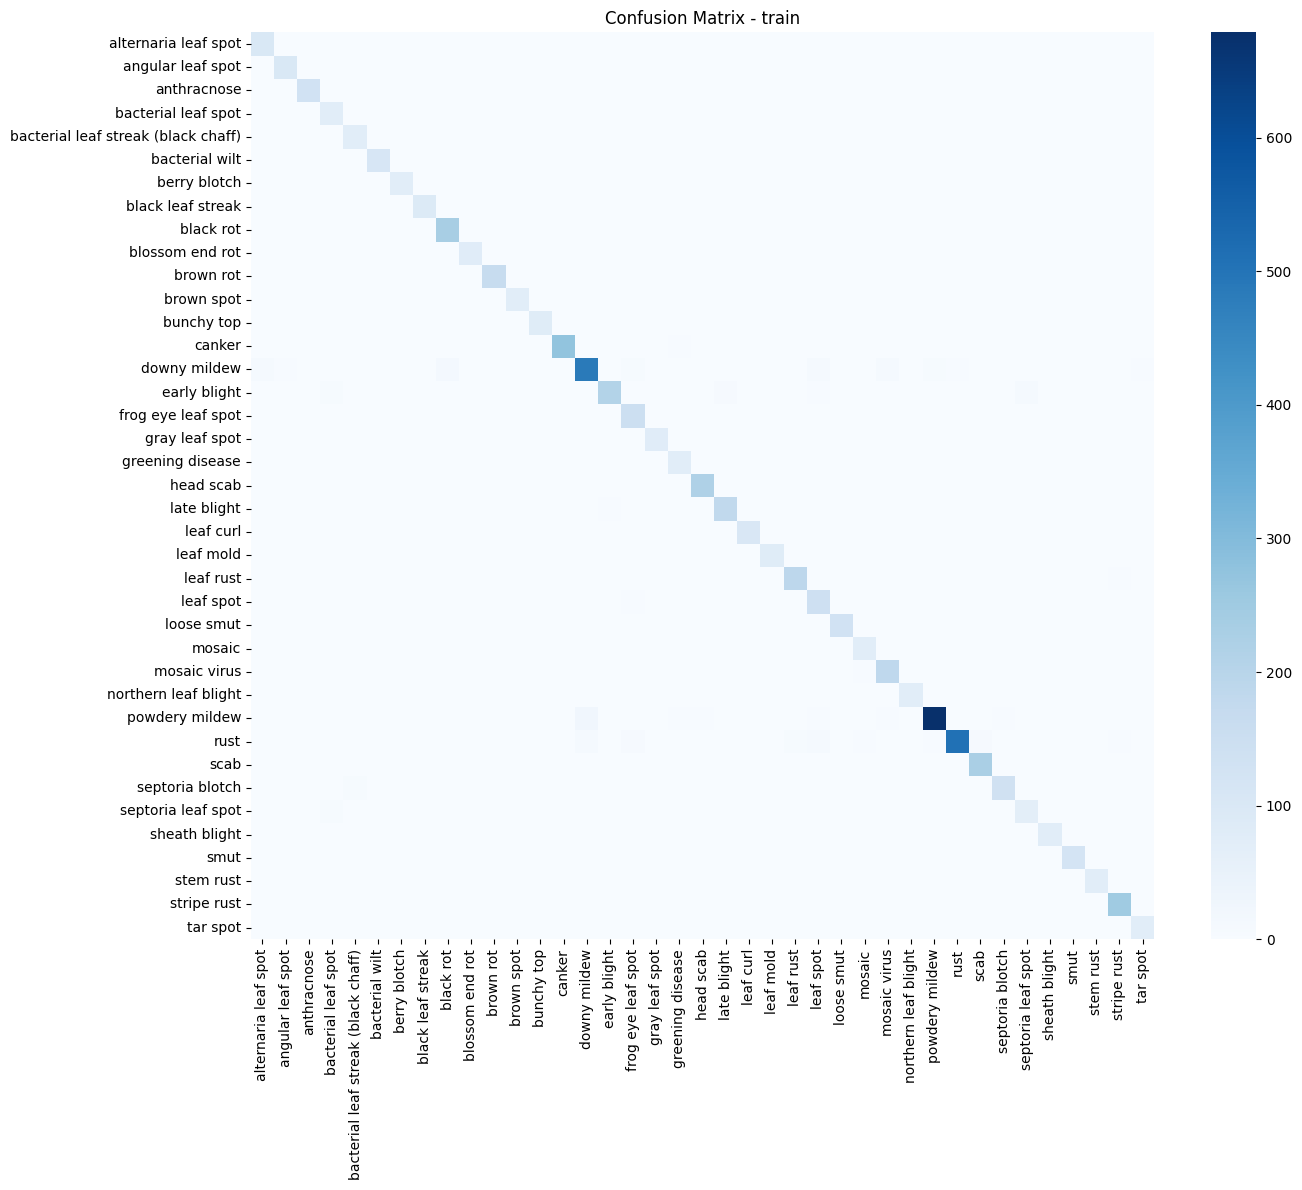

{'split': 'train', 'n_samples': 6615, 'top1_acc': 0.9490551776266062, 'top3_acc': 0.9941043083900227, 'top5_acc': 0.9987906273620559, 'misclassified_count': 337}


,precision,recall,f1-score,support
alternaria leaf spot,0.878261,0.971154,0.922374,104.0
angular leaf spot,0.944444,0.980769,0.962264,104.0
anthracnose,0.992366,1.000000,0.996169,130.0
bacterial leaf spot,0.815217,0.974026,0.887574,77.0
bacterial leaf streak (black chaff),0.903614,0.986842,0.943396,76.0
bacterial wilt,0.964912,1.000000,0.982143,110.0
berry blotch,0.950000,1.000000,0.974359,76.0
black leaf streak,1.000000,1.000000,1.000000,91.0
black rot,0.928571,0.970954,0.949290,241.0
blossom end rot,1.000000,1.000000,1.000000,77.0


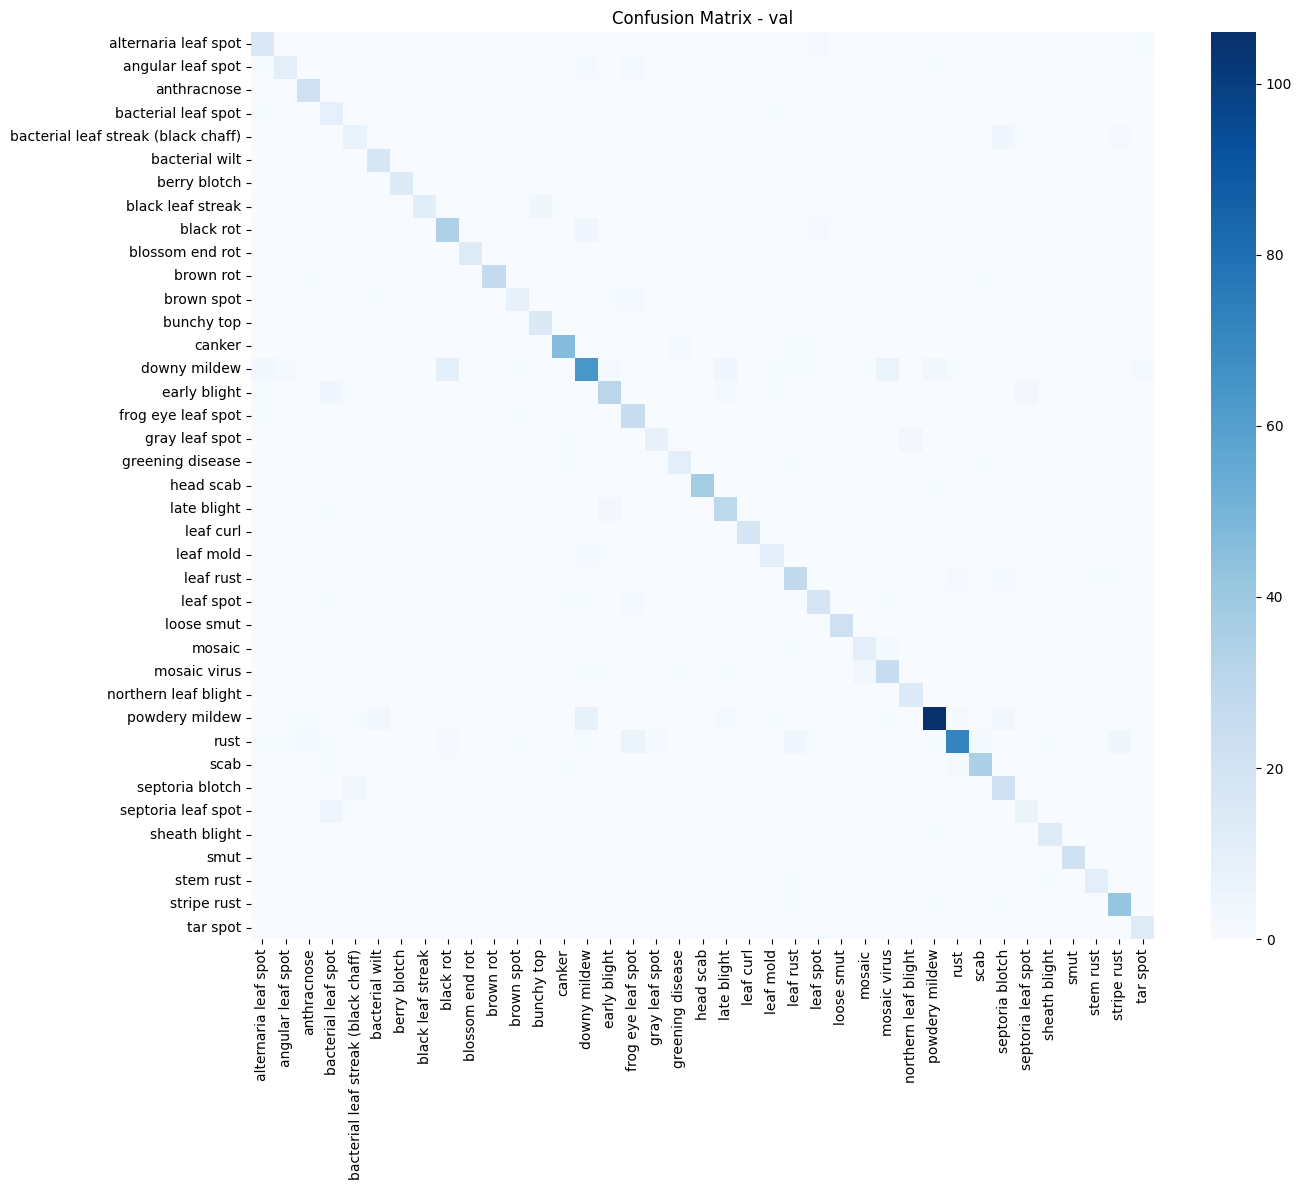

{'split': 'val', 'n_samples': 1168, 'top1_acc': 0.8073630136986302, 'top3_acc': 0.9546232876712328, 'top5_acc': 0.976027397260274, 'misclassified_count': 225}


,precision,recall,f1-score,support
alternaria leaf spot,0.652174,0.833333,0.731707,18.0
angular leaf spot,0.687500,0.611111,0.647059,18.0
anthracnose,0.840000,0.913043,0.875000,23.0
bacterial leaf spot,0.409091,0.692308,0.514286,13.0
bacterial leaf streak (black chaff),0.636364,0.500000,0.560000,14.0
bacterial wilt,0.809524,0.894737,0.850000,19.0
berry blotch,0.933333,1.000000,0.965517,14.0
black leaf streak,1.000000,0.750000,0.857143,16.0
black rot,0.693878,0.809524,0.747253,42.0
blossom end rot,1.000000,1.000000,1.000000,13.0


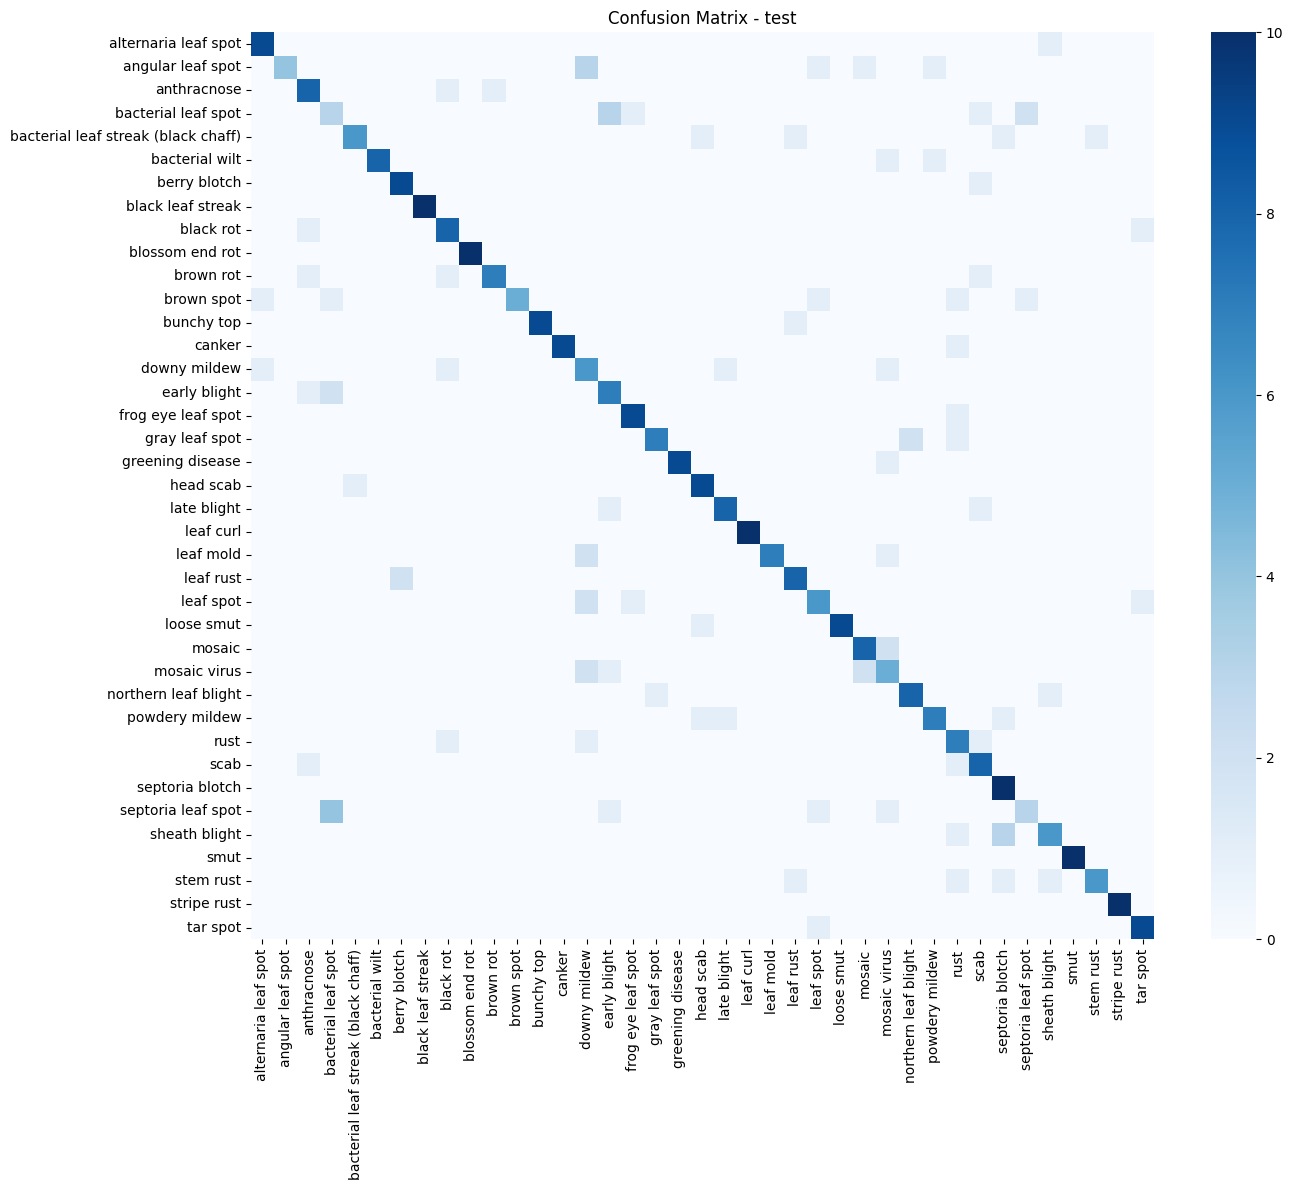

{'split': 'test', 'n_samples': 390, 'top1_acc': 0.7615384615384615, 'top3_acc': 0.9384615384615385, 'top5_acc': 0.9769230769230769, 'misclassified_count': 93}


,precision,recall,f1-score,support
alternaria leaf spot,0.818182,0.9,0.857143,10.0
angular leaf spot,1.000000,0.4,0.571429,10.0
anthracnose,0.666667,0.8,0.727273,10.0
bacterial leaf spot,0.300000,0.3,0.300000,10.0
bacterial leaf streak (black chaff),0.857143,0.6,0.705882,10.0
bacterial wilt,1.000000,0.8,0.888889,10.0
berry blotch,0.818182,0.9,0.857143,10.0
black leaf streak,1.000000,1.0,1.000000,10.0
black rot,0.666667,0.8,0.727273,10.0
blossom end rot,1.000000,1.0,1.000000,10.0


,split,n_samples,top1_acc,top3_acc,top5_acc,misclassified_count
0,train,6615,0.949055,0.994104,0.998791,337
1,val,1168,0.807363,0.954623,0.976027,225
2,test,390,0.761538,0.938462,0.976923,93


Run root: /content/drive/MyDrive/swin_tiny_runs/swin_tiny_two_stage


In [ ]:

all_metrics = []

if CFG["save_train_predictions"]:
    train_eval_loader = DataLoader(DiseaseDataset(train_sub_df, eval_tf), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)
    train_pred_df, _ = predict_df(model, train_sub_df, train_eval_loader, "train")
    all_metrics.append(analyze_split(train_pred_df, "train"))

val_pred_df, _ = predict_df(model, dev_sub_df, val_loader, "val")
all_metrics.append(analyze_split(val_pred_df, "val"))

test_pred_df, _ = predict_df(model, official_val_df, test_loader, "test")
all_metrics.append(analyze_split(test_pred_df, "test"))

pd.DataFrame(all_metrics).to_csv(run_root / "all_split_summary.csv", index=False)
display(pd.DataFrame(all_metrics))
print("Run root:", run_root)
